In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

from src.preprocess import merge_dataframes, compute_kinematics
from src.config import config


I0000 00:00:1776011498.697119 1427208 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776011498.697607 1427208 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776011498.735066 1427208 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776011499.600278 1427208 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [5]:
df = merge_dataframes()
print(df.head())

# df.drop(columns=["time", "case"], inplace=True)
# print(df.head())
# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_data = scaler.fit_transform(df.values)

    case  step  time          disp        cd        cl
0  Ur3.0     0  0.00  7.806175e-12  0.000000  0.000000
1  Ur3.0     1  0.02  7.806175e-12  5.629782  0.003150
2  Ur3.0     2  0.04  7.806175e-12  3.452590 -0.000466
3  Ur3.0     3  0.06  7.806175e-12  2.409503 -0.001204
4  Ur3.0     4  0.08  7.806175e-12  1.935443 -0.000587


In [36]:
raw_df = compute_kinematics(df)
feature_cols = ["disp", "vel", "acc"]
target_col = "cl"
time_step = 50

raw_df_orig = raw_df.copy()  # Keep unscaled copy
sort_df = raw_df.sort_values(["case", "time", "step"]).reset_index(drop=True).copy()

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Create a scaled version for training
sort_df_scaled = sort_df.copy()
sort_df_scaled[feature_cols] = x_scaler.fit_transform(sort_df[feature_cols])
sort_df_scaled[[target_col]] = y_scaler.fit_transform(sort_df[[target_col]])

def create_dataset_per_case(df, feature_cols, target_col, time_step, case_col="case"):
    Xs, ys, meta = [], [], []

    for case, Ur in df.groupby(case_col, sort=False):
        Ur = Ur.reset_index(drop=True)
        X = Ur[feature_cols].to_numpy(dtype=np.float32)
        y = Ur[[target_col]].to_numpy(dtype=np.float32)

        if len(Ur) < time_step:
            continue

        for i in range(len(Ur) - time_step):
            Xs.append(X[i:i+time_step])
            ys.append(y[i+time_step])
            meta.append((case, i + time_step))

    Xs = np.array(Xs, dtype=np.float32)
    ys = np.array(ys, dtype=np.float32)
    return Xs, ys, meta
X_seq, y_seq, meta_seq = create_dataset_per_case(sort_df, feature_cols, target_col, time_step=time_step)
# X_seq shape: (N, 50, n_features)

Computing velocity and acceleration...


In [31]:


model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    GRU(units=50),
    Dense(units=1),
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

/home/gambotch/Thesis/HPC_cluster/Cylinder/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
history = model.fit(X_seq, y_seq, epochs=4, batch_size=32, validation_split=0.2, shuffle=False)

Epoch 1/4
7981/7981 ━━━━━━━━━━━━━━━━━━━━ 155s 19ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 2/4
7981/7981 ━━━━━━━━━━━━━━━━━━━━ 156s 20ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 3/4
7981/7981 ━━━━━━━━━━━━━━━━━━━━ 152s 19ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 4/4
7981/7981 ━━━━━━━━━━━━━━━━━━━━ 153s 19ms/step - loss: 0.0023 - val_loss: 0.0021


In [33]:
case_name = sort_df["case"].iloc[-1]  # or set explicitly, e.g. "Ur6p0"
case_df = sort_df[sort_df["case"] == case_name].sort_values(["time", "step"])

x_last = case_df[feature_cols].to_numpy(dtype=np.float32)[-time_step:, :]
input_sequence = x_last.reshape(1, time_step, len(feature_cols))

pred_scaled = model.predict(input_sequence)
pred = y_scaler.inverse_transform(pred_scaled)

print(f"Case: {case_name}")
print(f"Predicted cl: {pred[0,0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Case: Ur9.0
Predicted cl: -0.0328


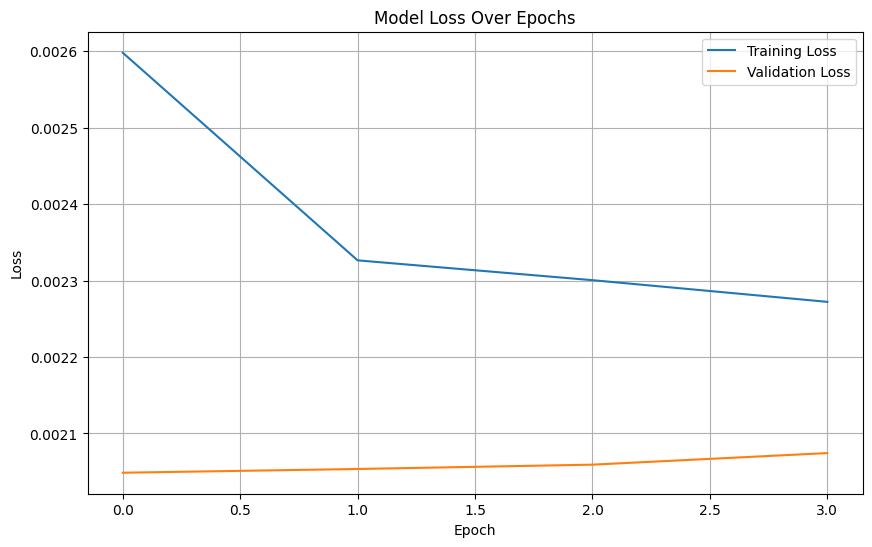

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [39]:
# Choose a case to evaluate
case_name = "Ur5.6"   # or: sort_df["case"].iloc[-1]
case_df = sort_df[sort_df["case"] == case_name].sort_values(["time", "step"]).reset_index(drop=True)

# Build evaluation windows for that case
X_case_raw = case_df[feature_cols].to_numpy(dtype=np.float32)
y_case_raw = case_df[[target_col]].to_numpy(dtype=np.float32)

# Scale with the same scalers used for training
if X_case_raw.shape[0] == 0:
    raise ValueError(
        f"No rows found for case '{case_name}'. Available cases: {df['case'].dropna().unique()[:10]}"
    )

X_case_scaled = x_scaler.transform(X_case_raw)
y_case_scaled = y_scaler.transform(y_case_raw)

X_eval, y_true = [], []
for i in range(len(case_df) - time_step):
    X_eval.append(X_case_scaled[i:i + time_step, :])
    y_true.append(y_case_raw[i + time_step, 0])  # true value in physical units

X_eval = np.array(X_eval, dtype=np.float32)
y_true = np.array(y_true, dtype=np.float32)

# Predict all windows
y_pred_scaled = model.predict(X_eval, verbose=0)
y_pred = y_scaler.inverse_transform(y_pred_scaled).ravel()

print("X_eval shape:", X_eval.shape)
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

/home/gambotch/Thesis/HPC_cluster/Cylinder/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/gambotch/Thesis/HPC_cluster/Cylinder/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


X_eval shape: (19951, 50, 3)
y_true shape: (19951,)
y_pred shape: (19951,)


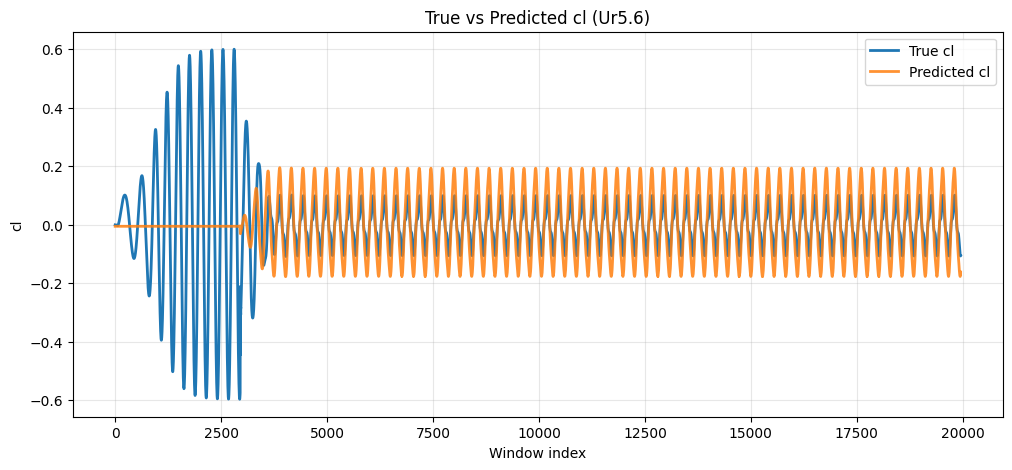

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True cl", linewidth=2)
plt.plot(y_pred, label="Predicted cl", linewidth=2, alpha=0.85)
plt.title(f"True vs Predicted cl ({case_name})")
plt.xlabel("Window index")
plt.ylabel("cl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()